In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/headphones.csv")

print(df.shape)

df.head()


(3000, 30)


,ID,Brand,Model,Type,Connectivity,Driver Type,Freq Low (Hz),Freq High (Hz),Impedance (Ω),Sensitivity (dB),...,Water Rating,Color,Price (USD),Release Year,Warranty (yrs),Avg Rating,Review Count,Primary Use,Form Factor,Open/Closed
0,1,Fiio,MDR 150Pro,Wired,3.5mm,Dynamic,4,40000,250,90.6,...,NaN,Cream,130,2016,3,4.4,1031,Work/Office,Over-Ear,Closed
1,2,Philips,HE 300 Open,Wired,3.5mm,Planar,4,35000,47,96.5,...,NaN,Midnight Blue,590,2023,3,3.6,235,Gaming,Over-Ear,Open
2,3,Apple,Drift 500,Wireless,Bluetooth,Balanced Armature,18,22000,22,104.3,...,IP55,Dark Green,240,2023,1,4.5,591,Gaming,In-Ear,Closed
3,4,1MORE,E834,Wired,3.5mm,Hybrid,15,30000,18,108.4,...,NaN,Champagne,100,2020,1,4.3,227,Gaming,In-Ear,Closed
4,5,Shokz,Drops 200,Wireless,Bluetooth,Balanced Armature,20,40000,22,111.7,...,NaN,Carbon,360,2023,1,4.5,4179,Music/Casual,In-Ear,Closed


In [3]:
# Basic Information

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Shape: (3000, 30)

Columns:
['ID', 'Brand', 'Model', 'Type', 'Connectivity', 'Driver Type', 'Freq Low (Hz)', 'Freq High (Hz)', 'Impedance (Ω)', 'Sensitivity (dB)', 'THD (%)', 'Cable Length (m)', 'Weight (g)', 'Microphone', 'Noise Cancellation', 'Foldable', 'Battery (hrs)', 'BT Version', 'Codecs', 'Charging Port', 'Water Rating', 'Color', 'Price (USD)', 'Release Year', 'Warranty (yrs)', 'Avg Rating', 'Review Count', 'Primary Use', 'Form Factor', 'Open/Closed']

Data Types:
ID                      int64
Brand                     str
Model                     str
Type                      str
Connectivity              str
Driver Type               str
Freq Low (Hz)           int64
Freq High (Hz)          int64
Impedance (Ω)           int64
Sensitivity (dB)      float64
THD (%)               float64
Cable Length (m)      float64
Weight (g)            float64
Microphone               bool
Noise Cancellation       bool
Foldable                 bool
Battery (hrs)         float64
BT Version   

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ID                       0
Brand                    0
Model                    0
Type                     0
Connectivity             0
Driver Type              0
Freq Low (Hz)            0
Freq High (Hz)           0
Impedance (Ω)            0
Sensitivity (dB)         0
THD (%)                  0
Cable Length (m)      1716
Weight (g)               0
Microphone               0
Noise Cancellation       0
Foldable                 0
Battery (hrs)         1284
BT Version            1284
Codecs                1284
Charging Port         1284
Water Rating          1402
Color                    0
Price (USD)              0
Release Year             0
Warranty (yrs)           0
Avg Rating               0
Review Count             0
Primary Use              0
Form Factor              0
Open/Closed              0
dtype: int64


In [5]:
print("\nColumns:")
print(df.columns.tolist())



Columns:
['ID', 'Brand', 'Model', 'Type', 'Connectivity', 'Driver Type', 'Freq Low (Hz)', 'Freq High (Hz)', 'Impedance (Ω)', 'Sensitivity (dB)', 'THD (%)', 'Cable Length (m)', 'Weight (g)', 'Microphone', 'Noise Cancellation', 'Foldable', 'Battery (hrs)', 'BT Version', 'Codecs', 'Charging Port', 'Water Rating', 'Color', 'Price (USD)', 'Release Year', 'Warranty (yrs)', 'Avg Rating', 'Review Count', 'Primary Use', 'Form Factor', 'Open/Closed']


In [6]:
# Keep only Wireless + In-Ear products

df = df[
    (df["Type"] == "Wireless") &
    (df["Form Factor"] == "In-Ear")
]

print("New Shape:", df.shape)

New Shape: (810, 30)


In [7]:
# Remove unnecessary columns

columns_to_drop = [
    "ID",
    "Cable Length (m)",
    "Open/Closed"
]

df = df.drop(columns=columns_to_drop)

print(df.shape)
df.head()

(810, 27)


,Brand,Model,Type,Connectivity,Driver Type,Freq Low (Hz),Freq High (Hz),Impedance (Ω),Sensitivity (dB),THD (%),...,Charging Port,Water Rating,Color,Price (USD),Release Year,Warranty (yrs),Avg Rating,Review Count,Primary Use,Form Factor
2,Apple,Drift 500,Wireless,Bluetooth,Balanced Armature,18,22000,22,104.3,0.0110,...,USB-C,IP55,Dark Green,240,2023,1,4.5,591,Gaming,In-Ear
4,Shokz,Drops 200,Wireless,Bluetooth,Balanced Armature,20,40000,22,111.7,0.0133,...,Lightning,NaN,Carbon,360,2023,1,4.5,4179,Music/Casual,In-Ear
9,Sony,Air Max,Wireless,Bluetooth,Balanced Armature,10,40000,22,111.1,0.0124,...,USB-C,NaN,Carbon,130,2023,2,4.1,2552,Commuting/Travel,In-Ear
18,Microsoft,Wave,Wireless,Bluetooth,Dynamic,20,20000,18,111.0,0.0045,...,USB-C,IPX2,Rose Gold,270,2021,2,4.8,14476,Bass/Casual,In-Ear
21,Tribit,Aura 300,Wireless,Bluetooth,Balanced Armature,10,20000,32,101.6,0.0085,...,Lightning,IPX7,Indigo,220,2021,1,4.5,662,Work/Office,In-Ear


In [8]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "percent", regex=False)
    .str.replace("ω", "ohm", regex=False)
    .str.replace("/", "_", regex=False)
)

In [9]:
df.columns.tolist()


['brand',
 'model',
 'type',
 'connectivity',
 'driver_type',
 'freq_low_hz',
 'freq_high_hz',
 'impedance_ohm',
 'sensitivity_db',
 'thd_percent',
 'weight_g',
 'microphone',
 'noise_cancellation',
 'foldable',
 'battery_hrs',
 'bt_version',
 'codecs',
 'charging_port',
 'water_rating',
 'color',
 'price_usd',
 'release_year',
 'warranty_yrs',
 'avg_rating',
 'review_count',
 'primary_use',
 'form_factor']

In [10]:
# Missing Values Percentage

missing = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing = missing[missing > 0]

print(missing)

water_rating    26.296296
dtype: float64


In [11]:
df["water_rating"] = df["water_rating"].fillna("Not Rated")

In [12]:
df.isnull().sum()

brand                 0
model                 0
type                  0
connectivity          0
driver_type           0
freq_low_hz           0
freq_high_hz          0
impedance_ohm         0
sensitivity_db        0
thd_percent           0
weight_g              0
microphone            0
noise_cancellation    0
foldable              0
battery_hrs           0
bt_version            0
codecs                0
charging_port         0
water_rating          0
color                 0
price_usd             0
release_year          0
warranty_yrs          0
avg_rating            0
review_count          0
primary_use           0
form_factor           0
dtype: int64

In [13]:
#price segment
def price_segment(price):
    if price < 100:
        return "Budget"
    elif price < 250:
        return "Mid-Range"
    else:
        return "Premium"

df["price_segment"] = df["price_usd"].apply(price_segment)

In [14]:
df["price_segment"].value_counts()

price_segment
Mid-Range    582
Premium      178
Budget        50
Name: count, dtype: int64

In [15]:
#Rating Category
def rating_category(rating):
    if rating >= 4.5:
        return "Excellent"
    elif rating >= 4.0:
        return "Good"
    elif rating >= 3.5:
        return "Average"
    else:
        return "Poor"

df["rating_category"] = df["avg_rating"].apply(rating_category)

In [16]:
df["rating_category"].value_counts()

rating_category
Good         407
Excellent    274
Average      129
Name: count, dtype: int64

In [17]:
# Battery Category
def battery_category(hours):
    if hours < 20:
        return "Low"
    elif hours < 40:
        return "Medium"
    else:
        return "High"

df["battery_category"] = df["battery_hrs"].apply(battery_category)

In [18]:
# verify
df["battery_category"].value_counts()

battery_category
Medium    469
High      175
Low       166
Name: count, dtype: int64

In [19]:
# Warranty Category
def warranty_category(years):
    if years == 1:
        return "Standard"
    elif years == 2:
        return "Extended"
    else:
        return "Premium"

df["warranty_category"] = df["warranty_yrs"].apply(warranty_category)

In [20]:
# verify
df["warranty_category"].value_counts()

warranty_category
Standard    464
Extended    346
Name: count, dtype: int64

In [21]:
brand_count = (
    df["brand"]
    .value_counts()
    .reset_index()
)

brand_count.columns = ["Brand", "Number of Products"]

brand_count.head(10)

,Brand,Number of Products
0,JBL,28
1,Audio-Technica,28
2,TOZO,25
3,Tribit,24
4,Jabra,23
5,Sennheiser,23
6,Nothing,22
7,Status Audio,22
8,Master & Dynamic,21
9,Apple,20


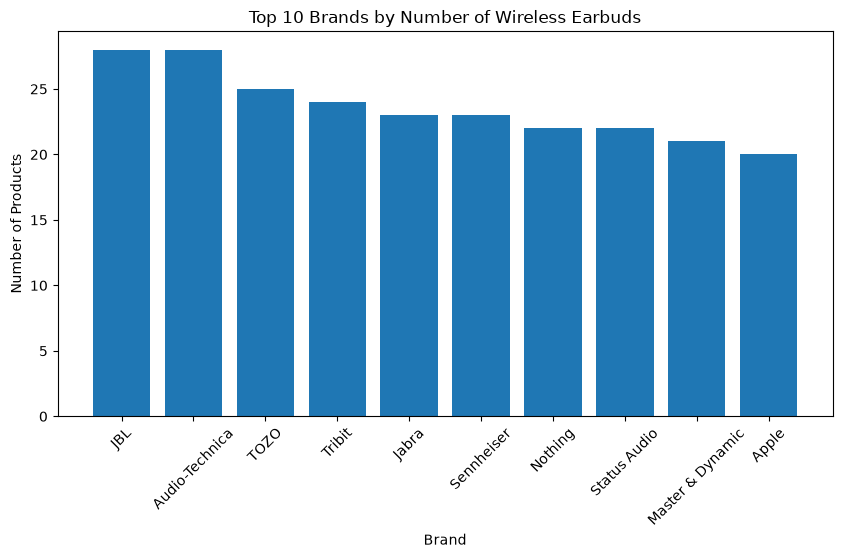

In [22]:
# Which brands have the highest number of wireless earbuds?
import matplotlib.pyplot as plt

top10 = df["brand"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)
plt.title("Top 10 Brands by Number of Wireless Earbuds")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)

plt.show()

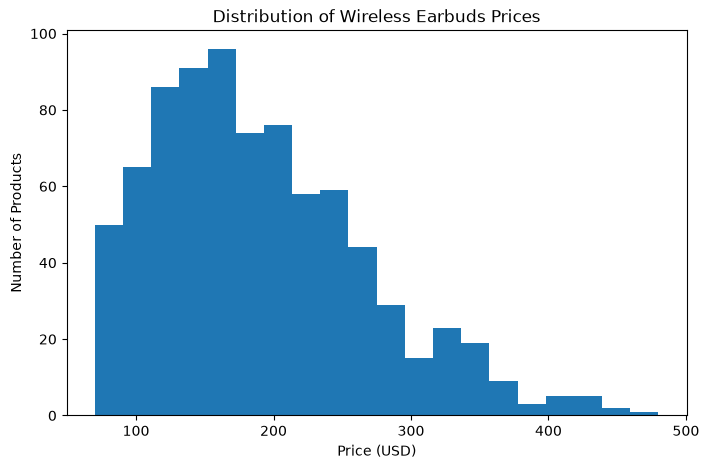

In [23]:
# How are wireless earbuds distributed across different price ranges?
plt.figure(figsize=(8,5))

plt.hist(df["price_usd"], bins=20)

plt.title("Distribution of Wireless Earbuds Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Products")

plt.show()

In [24]:
# Rating Analysis

rating_dist = (
    df["rating_category"]
    .value_counts()
    .reset_index()
)

rating_dist.columns = ["Rating Category", "Number of Products"]

rating_dist

,Rating Category,Number of Products
0,Good,407
1,Excellent,274
2,Average,129


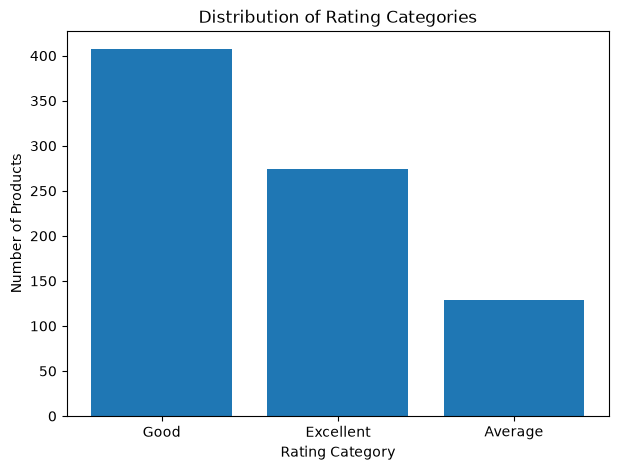

In [25]:
# How are product ratings distributed, and how many products fall into each rating category?
import matplotlib.pyplot as plt

rating_counts = df["rating_category"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Distribution of Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Products")

plt.show()

In [26]:
# Battery Life Analysis
battery_dist = (
    df["battery_category"]
    .value_counts()
    .reset_index()
)

battery_dist.columns = ["Battery Category", "Number of Products"]

battery_dist

,Battery Category,Number of Products
0,Medium,469
1,High,175
2,Low,166


In [27]:
# # How is battery life distributed among wireless earbuds, and which battery category dominates the market?
# import matplotlib.pyplot as plt

# battery_counts = df["battery_category"].value_counts()

# plt.figure(figsize=(7,5))

# plt.bar(battery_counts.index, battery_counts.values)

# plt.title("Battery Category Distribution")
# plt.xlabel("Battery Category")
# plt.ylabel("Number of Products")

# plt.show()

In [28]:
#Noise Cancellation Analysis
noise_dist = (
    df["noise_cancellation"]
    .value_counts()
    .reset_index()
)

noise_dist.columns = ["Noise Cancellation", "Number of Products"]

noise_dist

,Noise Cancellation,Number of Products
0,True,424
1,False,386


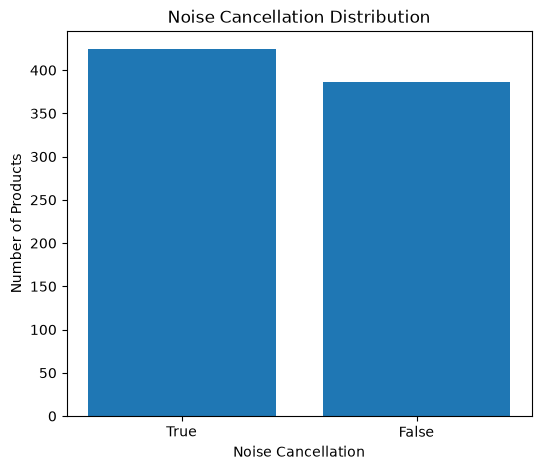

In [29]:
# How many wireless earbuds support Noise Cancellation, and what is the overall distribution?
import matplotlib.pyplot as plt

noise_counts = df["noise_cancellation"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(noise_counts.index.astype(str), noise_counts.values)

plt.title("Noise Cancellation Distribution")
plt.xlabel("Noise Cancellation")
plt.ylabel("Number of Products")

plt.show()

In [30]:
#Warranty Analysis
warranty_dist = (
    df["warranty_category"]
    .value_counts()
    .reset_index()
)

warranty_dist.columns = ["Warranty Category", "Number of Products"]

warranty_dist

,Warranty Category,Number of Products
0,Standard,464
1,Extended,346


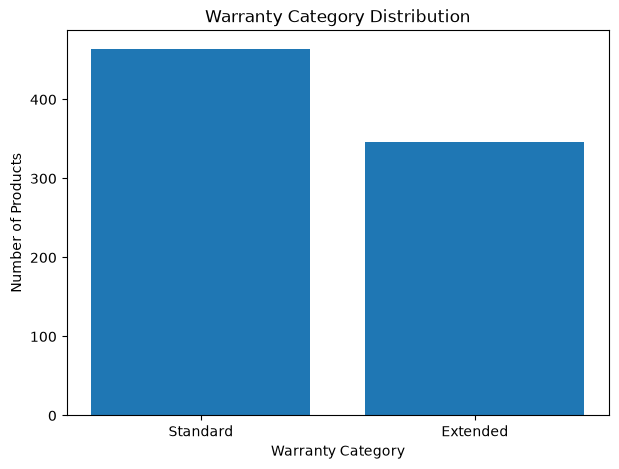

In [31]:
# How are wireless earbuds distributed across different warranty categories?
import matplotlib.pyplot as plt

warranty_counts = df["warranty_category"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(warranty_counts.index, warranty_counts.values)

plt.title("Warranty Category Distribution")
plt.xlabel("Warranty Category")
plt.ylabel("Number of Products")

plt.show()

In [32]:
df.to_csv("../data/cleaned/cleaned_earbuds.csv", index=False)

In [33]:
import random

brand_models = {
    "boAt": [
        "Airdopes 131","Airdopes 141","Airdopes 161","Airdopes 170",
        "Airdopes 280 ANC","Airdopes 311 Pro","Airdopes 441",
        "Airdopes Alpha","Nirvana Ion","Nirvana Zenith",
        "Nirvana Crystl","Airdopes Flex"
    ],

    "Noise": [
        "Buds VS102","Buds VS104","Buds VS201","Buds VS402",
        "Air Buds Pro","Air Buds Max","Air Buds Lite",
        "Pure Pods","Combat Z","Combat X"
    ],

    "JBL": [
        "Wave Beam","Wave Buds","Tune Flex","Tune Beam",
        "Live Pro 2","Live Beam 3","Endurance Peak 3",
        "Vibe Beam","Tour Pro 2"
    ],

    "Sony": [
        "WF-C500","WF-C700N","WF-1000XM4","WF-1000XM5",
        "LinkBuds","LinkBuds S","WF-XB700"
    ],

    "Apple": [
        "AirPods 2","AirPods 3","AirPods 4",
        "AirPods Pro","AirPods Pro 2"
    ],

    "Samsung": [
        "Galaxy Buds Live","Galaxy Buds 2",
        "Galaxy Buds2 Pro","Galaxy Buds FE",
        "Galaxy Buds3","Galaxy Buds3 Pro"
    ],

    "OnePlus": [
        "Buds Z2","Buds Pro","Buds Pro 2",
        "Buds 3","Nord Buds","Nord Buds 2",
        "Nord Buds 2R"
    ],

    "Realme": [
        "Buds Air 3","Buds Air 5","Buds Air 6",
        "Buds T100","Buds T300","Buds T310"
    ],

    "Oppo": [
        "Enco Air 2","Enco Air 3",
        "Enco X","Enco X2","Enco Buds2"
    ],

    "Nothing": [
        "Ear 1","Ear 2","Ear","Ear (a)"
    ],

    "CMF": [
        "Buds","Buds Pro","Buds Pro 2"
    ],

    "Redmi": [
        "Buds 4","Buds 5","Buds 5 Pro",
        "Buds 6","Buds 6 Play"
    ],

    "Xiaomi": [
        "Redmi Buds Essential",
        "Buds 4 Pro",
        "Buds 5 Pro"
    ],

    "Boult": [
        "Z20","Z40","Z40 Pro",
        "X Mustang","Omega","Curve Max"
    ],

    "pTron": [
        "Bassbuds Duo","Bassbuds Jade",
        "Bassbuds Tango","Zenbuds Evo"
    ],

    "Anker Soundcore": [
        "Life P2","Life P3",
        "Liberty 4","Liberty 4 NC",
        "P40i"
    ],

    "Skullcandy": [
        "Dime","Dime 2","Dime 3",
        "Rail","Sesh Evo"
    ],

    "Jabra": [
        "Elite 3","Elite 4",
        "Elite 5","Elite 7 Pro",
        "Elite 8 Active"
    ],

    "Sennheiser": [
        "CX True Wireless",
        "CX Plus",
        "Momentum True Wireless 3",
        "Momentum True Wireless 4"
    ],

    "Philips": [
        "TAT1108","TAT2206",
        "TAT3508","TAT4556"
    ],

    "Huawei": [
        "FreeBuds 4i",
        "FreeBuds 5i",
        "FreeBuds Pro 2"
    ],

    "Beats": [
        "Studio Buds",
        "Studio Buds Plus",
        "Fit Pro"
    ],

    "Edifier": [
        "X3","X5 Pro",
        "NeoBuds Pro",
        "TWS1 Pro"
    ],

    "Logitech": [
        "Zone True Wireless",
        "G Fits"
    ],

    "Shokz": [
        "OpenFit",
        "OpenFit Air",
        "OpenDots One"
    ]
}

brands = list(brand_models.keys())

df["brand"] = [random.choice(brands) for _ in range(len(df))]
df["model"] = [
    random.choice(brand_models[b])
    for b in df["brand"]
]

In [34]:
df[["brand","model"]].sample(20)

,brand,model
2806,Nothing,Ear 2
277,Redmi,Buds 5
2324,Realme,Buds Air 3
982,Jabra,Elite 5
2674,Jabra,Elite 8 Active
2530,Beats,Fit Pro
2750,Boult,X Mustang
2677,Redmi,Buds 6
1933,boAt,Airdopes Flex
930,Sony,WF-XB700


In [35]:
df.head(10)

,brand,model,type,connectivity,driver_type,freq_low_hz,freq_high_hz,impedance_ohm,sensitivity_db,thd_percent,...,release_year,warranty_yrs,avg_rating,review_count,primary_use,form_factor,price_segment,rating_category,battery_category,warranty_category
2,Oppo,Enco Air 3,Wireless,Bluetooth,Balanced Armature,18,22000,22,104.3,0.0110,...,2023,1,4.5,591,Gaming,In-Ear,Mid-Range,Excellent,Medium,Standard
4,Skullcandy,Rail,Wireless,Bluetooth,Balanced Armature,20,40000,22,111.7,0.0133,...,2023,1,4.5,4179,Music/Casual,In-Ear,Premium,Excellent,Medium,Standard
9,Apple,AirPods 2,Wireless,Bluetooth,Balanced Armature,10,40000,22,111.1,0.0124,...,2023,2,4.1,2552,Commuting/Travel,In-Ear,Mid-Range,Good,Medium,Extended
18,Jabra,Elite 7 Pro,Wireless,Bluetooth,Dynamic,20,20000,18,111.0,0.0045,...,2021,2,4.8,14476,Bass/Casual,In-Ear,Premium,Excellent,Medium,Extended
21,JBL,Tour Pro 2,Wireless,Bluetooth,Balanced Armature,10,20000,32,101.6,0.0085,...,2021,1,4.5,662,Work/Office,In-Ear,Mid-Range,Excellent,Medium,Standard
24,Shokz,OpenFit Air,Wireless,Bluetooth,Hybrid,20,22000,22,107.4,0.0140,...,2021,2,4.1,6253,Studio/Pro,In-Ear,Premium,Good,Medium,Extended
27,Samsung,Galaxy Buds Live,Wireless,Bluetooth,Hybrid,15,24000,16,111.7,0.0096,...,2019,2,4.4,1615,Commuting/Travel,In-Ear,Mid-Range,Good,Medium,Extended
28,boAt,Nirvana Crystl,Wireless,Bluetooth,Dynamic,10,40000,18,109.3,0.0076,...,2020,2,3.8,7664,Music/Audiophile,In-Ear,Premium,Average,Low,Extended
30,Oppo,Enco Air 2,Wireless,Bluetooth,Dynamic,20,40000,16,107.2,0.0137,...,2022,1,4.8,9210,Work/Office,In-Ear,Mid-Range,Excellent,Medium,Standard
31,Oppo,Enco Air 3,Wireless,Bluetooth,Planar,20,24000,22,108.0,0.0133,...,2023,2,4.2,581,Music/Casual,In-Ear,Mid-Range,Good,High,Extended


In [36]:
df["product_name"] = df["brand"] + " " + df["model"]

In [37]:
df.head(20)

,brand,model,type,connectivity,driver_type,freq_low_hz,freq_high_hz,impedance_ohm,sensitivity_db,thd_percent,...,warranty_yrs,avg_rating,review_count,primary_use,form_factor,price_segment,rating_category,battery_category,warranty_category,product_name
2,Oppo,Enco Air 3,Wireless,Bluetooth,Balanced Armature,18,22000,22,104.3,0.0110,...,1,4.5,591,Gaming,In-Ear,Mid-Range,Excellent,Medium,Standard,Oppo Enco Air 3
4,Skullcandy,Rail,Wireless,Bluetooth,Balanced Armature,20,40000,22,111.7,0.0133,...,1,4.5,4179,Music/Casual,In-Ear,Premium,Excellent,Medium,Standard,Skullcandy Rail
9,Apple,AirPods 2,Wireless,Bluetooth,Balanced Armature,10,40000,22,111.1,0.0124,...,2,4.1,2552,Commuting/Travel,In-Ear,Mid-Range,Good,Medium,Extended,Apple AirPods 2
18,Jabra,Elite 7 Pro,Wireless,Bluetooth,Dynamic,20,20000,18,111.0,0.0045,...,2,4.8,14476,Bass/Casual,In-Ear,Premium,Excellent,Medium,Extended,Jabra Elite 7 Pro
21,JBL,Tour Pro 2,Wireless,Bluetooth,Balanced Armature,10,20000,32,101.6,0.0085,...,1,4.5,662,Work/Office,In-Ear,Mid-Range,Excellent,Medium,Standard,JBL Tour Pro 2
24,Shokz,OpenFit Air,Wireless,Bluetooth,Hybrid,20,22000,22,107.4,0.0140,...,2,4.1,6253,Studio/Pro,In-Ear,Premium,Good,Medium,Extended,Shokz OpenFit Air
27,Samsung,Galaxy Buds Live,Wireless,Bluetooth,Hybrid,15,24000,16,111.7,0.0096,...,2,4.4,1615,Commuting/Travel,In-Ear,Mid-Range,Good,Medium,Extended,Samsung Galaxy Buds Live
28,boAt,Nirvana Crystl,Wireless,Bluetooth,Dynamic,10,40000,18,109.3,0.0076,...,2,3.8,7664,Music/Audiophile,In-Ear,Premium,Average,Low,Extended,boAt Nirvana Crystl
30,Oppo,Enco Air 2,Wireless,Bluetooth,Dynamic,20,40000,16,107.2,0.0137,...,1,4.8,9210,Work/Office,In-Ear,Mid-Range,Excellent,Medium,Standard,Oppo Enco Air 2
31,Oppo,Enco Air 3,Wireless,Bluetooth,Planar,20,24000,22,108.0,0.0133,...,2,4.2,581,Music/Casual,In-Ear,Mid-Range,Good,High,Extended,Oppo Enco Air 3


In [38]:
df.to_csv("../data/cleaned/cleaned_earbuds.csv", index=False)

In [40]:
df = pd.read_csv("C:\Wireless Audio Devices Market Analysis & Price Intelligence\data\cleaned\wireless_headphones.csv")

<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
C:\Users\A\AppData\Local\Temp\ipykernel_7220\236481938.py:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
  df = pd.read_csv("C:\Wireless Audio Devices Market Analysis & Price Intelligence\data\cleaned\wireless_headphones.csv")


In [41]:
df.head(10)

,product_name,brand,model,color,noise_cancellation,battery_hrs,bt_version,charging_port,water_rating,price_usd,release_year,warranty_yrs,avg_rating,review_count,primary_use,price_segment,rating_category,battery_category,warranty_category
0,Oppo Enco Air 3,Oppo,Enco Air 3,Dark Green,Yes,21.5,5.0,USB-C,IP55,240,2023,1,4.5,591,Gaming,Mid-Range,Excellent,Medium,Standard
1,Skullcandy Rail,Skullcandy,Rail,Carbon,Yes,33.5,5.3,Lightning,Not Rated,360,2023,1,4.5,4179,Music/Casual,Premium,Excellent,Medium,Standard
2,Apple AirPods 2,Apple,AirPods 2,Carbon,No,28.8,5.0,USB-C,Not Rated,130,2023,2,4.1,2552,Commuting/Travel,Mid-Range,Good,Medium,Extended
3,Jabra Elite 7 Pro,Jabra,Elite 7 Pro,Rose Gold,Yes,34.5,4.2,USB-C,IPX2,270,2021,2,4.8,14476,Bass/Casual,Premium,Excellent,Medium,Extended
4,JBL Tour Pro 2,JBL,Tour Pro 2,Indigo,Yes,33.3,4.2,Lightning,IPX7,220,2021,1,4.5,662,Work/Office,Mid-Range,Excellent,Medium,Standard
5,Shokz OpenFit Air,Shokz,OpenFit Air,Space Gray,Yes,29.0,5.2,Micro-USB,IP55,260,2021,2,4.1,6253,Studio/Pro,Premium,Good,Medium,Extended
6,Samsung Galaxy Buds Live,Samsung,Galaxy Buds Live,Cream,No,23.4,5.2,USB-C,Not Rated,210,2019,2,4.4,1615,Commuting/Travel,Mid-Range,Good,Medium,Extended
7,boAt Nirvana Crystl,boAt,Nirvana Crystl,Navy,Yes,13.4,5.0,USB-C,Not Rated,300,2020,2,3.8,7664,Music/Audiophile,Premium,Average,Low,Extended
8,Oppo Enco Air 2,Oppo,Enco Air 2,Cream,No,28.3,5.1,USB-C,IP57,100,2022,1,4.8,9210,Work/Office,Mid-Range,Excellent,Medium,Standard
9,Oppo Enco Air 3,Oppo,Enco Air 3,Red,Yes,57.6,5.2,USB-C,IP55,240,2023,2,4.2,581,Music/Casual,Mid-Range,Good,High,Extended


In [46]:
#print columns
df.columns.tolist()

['product_name',
 'brand',
 'model',
 'color',
 'noise_cancellation',
 'battery_hrs',
 'bt_version',
 'charging_port',
 'water_rating',
 'price_usd',
 'release_year',
 'warranty_yrs',
 'avg_rating',
 'review_count',
 'primary_use',
 'price_segment',
 'rating_category',
 'battery_category',
 'warranty_category']